In [1]:
import torch 
import torch.nn as nn
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F 
from transformers import CLIPTokenizer
import StableDiffusion.Utils 
import importlib 
importlib.reload(StableDiffusion.Utils)
from StableDiffusion.Utils import *

class ZeroConvLayer(nn.Module):
    def __init__(self,inFeatures:int,outFeatures:int,kernelSize=3,stride=1,padding = 1,bias=True):
        super(ZeroConvLayer,self).__init__()
        self.zeroConv = nn.Conv2d(inFeatures,outFeatures,kernel_size=kernelSize,
                                  stride = stride,padding = padding,bias=bias)
        nn.init.zeros_(self.zeroConv.weight)
        nn.init.zeros_(self.zeroConv.bias)
    
    
    def forward(self,input:torch.Tensor)->torch.Tensor:
        output = self.zeroConv(input)
        return output
        



 
 
class CannyEdgeDetection:
    def __init__(self,lowThreshold:int=100,highThreshold:int =200):
        self.lowThreshold = lowThreshold
        self.highThreshold = highThreshold    
    
    def __call__(self,img:np.ndarray)->torch.Tensor:
        canny = cv2.Canny(img,self.lowThreshold,self.highThreshold)
        canny = canny[:,:,None]
        cannyHW3 = np.concatenate([canny,canny,canny],axis = -1)
        cannyHW3 = cannyHW3.astype(np.float32)/255.0
        cannyTensor = torch.from_numpy(cannyHW3)
        cannyTensor = cannyTensor.permute(2,0,1)
        cannyTensor =cannyTensor[None,:,:,:] 
        cannyTensor = cannyTensor*2.0 - 1.0
        # output range [-1,1]
        return cannyTensor

class CannyToLatent(nn.Module):
    def __init__(self,):
        super(CannyToLatent,self).__init__()
        self.cannyToLatent = nn.ModuleList([
            
            #maintain stage B,3,512,512 ->B,16,512,512
            nn.Conv2d(in_channels =3,out_channels =16,kernel_size=3,padding = 1),
            nn.SiLU(), 
            nn.Conv2d(in_channels =16,out_channels =16,kernel_size=3,padding = 1),
            nn.SiLU(),   
            
            #down sampling 512->256
            #B,16,512,512 -> B,32,256,256
            nn.Conv2d(in_channels =16,out_channels =32,kernel_size=3,stride = 2,padding = 1),
            nn.SiLU(),
            nn.Conv2d(in_channels =32,out_channels =32,kernel_size=3,padding = 1),
            nn.SiLU(),               
            
            #down sampling 256->128
            #B,32,256,256 -> B,96,128,128
            nn.Conv2d(in_channels =32,out_channels =96,kernel_size=3,stride = 2,padding = 1),
            nn.SiLU(),
            nn.Conv2d(in_channels =96,out_channels =96,kernel_size=3,padding = 1),
            nn.SiLU(),     
            
            # down sampling 128->64
            #B,96,128,128 -> B,256,64,64
            nn.Conv2d(in_channels =96,out_channels =256,kernel_size=3,stride = 2,padding = 1),
            nn.SiLU(),
            
            #B,256,64,64 -> B,320,64,64
            ZeroConvLayer(inFeatures = 256,outFeatures=320,
                          kernelSize=3,stride = 1,
                          padding = 1,bias=True),
            
        ])
   
    def forward(self,input:torch.Tensor)->torch.Tensor:
        for layer in self.cannyToLatent:
            input = layer(input)
        return input




class ControlnetTimeEmbedding(nn.Module):
    def __init__(self,embeddingDimension = 320):
        super(ControlnetTimeEmbedding,self).__init__()
        self.embeddingDimension = embeddingDimension
        self.linear_1  = nn.Linear(self.embeddingDimension, 4 * self.embeddingDimension)
        #diffusion_model.time_embed.0  1280 320
        self.linear_2  = nn.Linear(4 * self.embeddingDimension, 4 * self.embeddingDimension)
        #diffusion_model.time_embed.2  1280 1280
    def forward(self,inputTime:int)->torch.Tensor:
        device = next(self.parameters()).device
        inputTimeEmb320=Utils.getTimeEmbeddingTorch(inputTime,device=device)
        x = inputTimeEmb320
        # 1,320
        x = self.linear_1(x)
        #1,1280
        x = F.silu(x)
        #add 20260218
        x = self.linear_2(x)
        #1,1280
        return x 

        
    
    
              
        

/home/aistudio/external-libraries/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
controlnetTimeEmbedding = ControlnetTimeEmbedding()
with torch.no_grad():    
    timeEmbed = controlnetTimeEmbedding(10)
    print(timeEmbed)

tensor([[ 0.1157,  0.0809, -0.2224,  ...,  0.0565, -0.0121,  0.3014]])


In [30]:
import StableDiffusion.ControlnetModelConverter
import importlib
importlib.reload(StableDiffusion.ControlnetModelConverter)
from StableDiffusion.ControlnetModelConverter import ControlnetModelConverter
dictPath = "../models/ControlNet-v1-1/control_v11p_sd15_canny.pth"
controlnetDict = ControlnetModelConverter(dictPath)
for key,param in controlnetDict.items():
    print(key,param.shape)

cannyToLatent.0.weight torch.Size([16, 3, 3, 3])
cannyToLatent.0.bias torch.Size([16])
cannyToLatent.2.weight torch.Size([16, 16, 3, 3])
cannyToLatent.2.bias torch.Size([16])
cannyToLatent.4.weight torch.Size([32, 16, 3, 3])
cannyToLatent.4.bias torch.Size([32])
cannyToLatent.6.weight torch.Size([32, 32, 3, 3])
cannyToLatent.6.bias torch.Size([32])
cannyToLatent.8.weight torch.Size([96, 32, 3, 3])
cannyToLatent.8.bias torch.Size([96])
cannyToLatent.10.weight torch.Size([96, 96, 3, 3])
cannyToLatent.10.bias torch.Size([96])
cannyToLatent.12.weight torch.Size([256, 96, 3, 3])
cannyToLatent.12.bias torch.Size([256])
cannyToLatent.14.zeroConv.weight torch.Size([320, 256, 3, 3])
cannyToLatent.14.zeroConv.bias torch.Size([320])


torch.Size([4, 128, 64, 64])
torch.Size([1, 3, 512, 512])


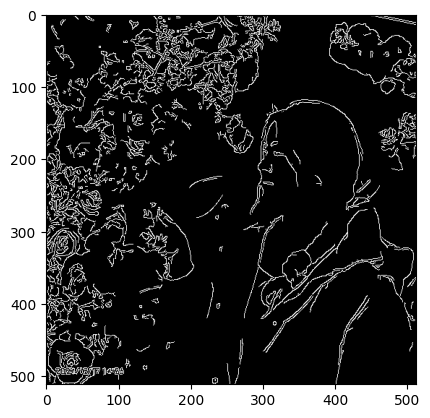

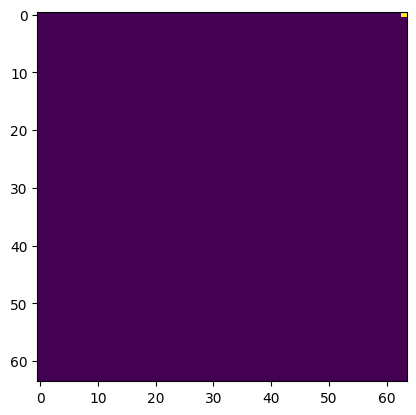

cannyToLatent.0.weight torch.Size([16, 3, 3, 3])
cannyToLatent.0.bias torch.Size([16])
cannyToLatent.2.weight torch.Size([16, 16, 3, 3])
cannyToLatent.2.bias torch.Size([16])
cannyToLatent.4.weight torch.Size([32, 16, 3, 3])
cannyToLatent.4.bias torch.Size([32])
cannyToLatent.6.weight torch.Size([32, 32, 3, 3])
cannyToLatent.6.bias torch.Size([32])
cannyToLatent.8.weight torch.Size([96, 32, 3, 3])
cannyToLatent.8.bias torch.Size([96])
cannyToLatent.10.weight torch.Size([96, 96, 3, 3])
cannyToLatent.10.bias torch.Size([96])
cannyToLatent.12.weight torch.Size([256, 96, 3, 3])
cannyToLatent.12.bias torch.Size([256])
cannyToLatent.14.zeroConv.weight torch.Size([320, 256, 3, 3])
cannyToLatent.14.zeroConv.bias torch.Size([320])


In [28]:
import StableDiffusion.Utils
import importlib
importlib.reload(StableDiffusion.Utils)
from StableDiffusion.Utils import Utils
cannyCond = torch.randn(4, 4, 64, 64)
zeroConvLayer = ZeroConvLayer(4,128)
output = zeroConvLayer(cannyCond)
print(output.shape)

filePath = './images/pusiyue_rose_1024_1024.jpg'
img = cv2.imread(filePath)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (512, 512))
cannyDetector = CannyEdgeDetection()
edgeImg = cannyDetector(img)
print(edgeImg.shape)
Utils.showBatchImage(edgeImg)

cannyToLatent = CannyToLatent()
cannyToLatent.load_state_dict(controlnetDict,strict=True)
cannyToLatent.eval()
with torch.no_grad():
    cannyLatentImg = cannyToLatent(edgeImg)
Utils.showBatchImage(cannyLatentImg[:1,9:10,:,:])
for name,param in cannyToLatent.named_parameters():
    print(name,param.shape)
#plt.imshow(edgeImg,cmap='gray')
#plt.show()
#print(edgeImg)

cannyToLatent.0.weight torch.Size([16, 3, 3, 3])
cannyToLatent.0.bias torch.Size([16])
cannyToLatent.2.weight torch.Size([16, 16, 3, 3])
cannyToLatent.2.bias torch.Size([16])
cannyToLatent.4.weight torch.Size([32, 16, 3, 3])
cannyToLatent.4.bias torch.Size([32])
cannyToLatent.6.weight torch.Size([32, 32, 3, 3])
cannyToLatent.6.bias torch.Size([32])
cannyToLatent.8.weight torch.Size([96, 32, 3, 3])
cannyToLatent.8.bias torch.Size([96])
cannyToLatent.10.weight torch.Size([96, 96, 3, 3])
cannyToLatent.10.bias torch.Size([96])
cannyToLatent.12.weight torch.Size([256, 96, 3, 3])
cannyToLatent.12.bias torch.Size([256])
cannyToLatent.zeroConv.14.weight torch.Size([320, 256, 3, 3])
cannyToLatent.zeroConv.14.bias torch.Size([320])


In [7]:
import torch

state_dict = torch.load("../models/ControlNet-v1-1/control_v11p_sd15_canny.pth", map_location="cpu")


for key,value in state_dict.items():
    print(key,value.shape)
#print(type(state_dict))
#print(state_dict.keys())

control_model.time_embed.0.weight torch.Size([1280, 320])
control_model.time_embed.0.bias torch.Size([1280])
control_model.time_embed.2.weight torch.Size([1280, 1280])
control_model.time_embed.2.bias torch.Size([1280])
control_model.input_blocks.0.0.weight torch.Size([320, 4, 3, 3])
control_model.input_blocks.0.0.bias torch.Size([320])
control_model.input_blocks.1.0.in_layers.0.weight torch.Size([320])
control_model.input_blocks.1.0.in_layers.0.bias torch.Size([320])
control_model.input_blocks.1.0.in_layers.2.weight torch.Size([320, 320, 3, 3])
control_model.input_blocks.1.0.in_layers.2.bias torch.Size([320])
control_model.input_blocks.1.0.emb_layers.1.weight torch.Size([320, 1280])
control_model.input_blocks.1.0.emb_layers.1.bias torch.Size([320])
control_model.input_blocks.1.0.out_layers.0.weight torch.Size([320])
control_model.input_blocks.1.0.out_layers.0.bias torch.Size([320])
control_model.input_blocks.1.0.out_layers.3.weight torch.Size([320, 320, 3, 3])
control_model.input_block